In [250]:
# !!! Helper functions to pull metrics from evaluation files !!!

import os
import re


def get_single_metrics(file_path, labels, thresholds):
    """
    Pulls precision and recall data from an evaluation text file (assumed to follow a predefined format - see validation.py)

    Parameters:
    - file_path: An absolute path to an evaluation file.
    - labels: A list of the model's labels
    - thresholds: A list of the model's thresholds

    Returns:
    - metrics: A dictionary containing lists of precision and recall values at each score threshold.
      The dictionary has an entry '{label}_precision' and '{label}_recall' for each label.
    """
    
    with open(file_path, 'r') as f:
        lines = f.readlines()

    metrics = {}
    for label in labels:
        metrics[f'{label}_precision'] = []
        metrics[f'{label}_recall'] = []
    
    for threshold in thresholds:
        
        # Regular expression patterns
        threshold_header_pattern = re.compile(rf'Validation Metrics @ Score Threshold = {threshold}')
        label_pattern = '|'.join([re.escape(label) for label in labels])
        metric_line_pattern = re.compile(
            rf'^({label_pattern})\s*\|\s*Precision:\s*([\d.]+)\s*\|\s*Recall:\s*([\d.]+)'
        )
        
        in_threshold_block = False 
        for line in lines:
            line = line.strip()
            
            if threshold_header_pattern.match(line):
                in_threshold_block = True
                continue
            
            if in_threshold_block:
                if line == '' or line.startswith('Validation Metrics'):
                    break  # End of the current threshold block
                
                match = metric_line_pattern.match(line)
                if match:
                    label, prec, rec = match.groups()
                    metrics[f'{label}_precision'].append(float(prec))
                    metrics[f'{label}_recall'].append(float(rec))

    return metrics



def get_epoch_metrics(model_name, evaluation_folder_path):
    """
    Pulls precision and recall data for each epoch of a model from a series of evaluation text files
    (assumed to follow a predefined format - see validation.py)
    
    The evaluation folder structure is assumed to follow the format below:
    evaluation
    ⤷ {model_name}
       ⤷ validation_{model_name}_epoch_0.txt
       ⤷ validation_{model_name}_epoch_1.txt
       ⤷ [...]

    Parameters:
    - model_name: The name of the model, also the name of the subfolder within the evaluation folder where the PR data is found
    - evaluation_folder_path: The location of the evaluation folder, which contains evaluation folders for each model

    Returns:
    - all_metrics: A list of metrics dictionaries, one for each epoch (see get_single_metrics for dict structure)

    """

    # file structure specifics
    folder_path = f'{evaluation_folder_path}/{model_name}'
    file_pattern = re.compile(f'validation_{model_name}' + r'_epoch_(\d+)\.txt')
    labels = ['D', '40Hz', '20Hz', 'A', 'B']
    thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    
    file_epoch_pairs = []
    for file_name in os.listdir(folder_path):
        match = file_pattern.match(file_name)
        if match:
            epoch = int(match.group(1))
            file_epoch_pairs.append((epoch, file_name))

    # sorting PR data by epoch
    def get_epoch_number(pair):
        return pair[0]
    file_epoch_pairs.sort(key=get_epoch_number)
    file_list = []
    for pair in file_epoch_pairs:
        file_list.append(pair[1])
    num_epochs = len(file_list)
    
    # appending PR metrics to new list
    all_metrics = []
    for file_path in file_list:
        all_metrics.append(get_single_metrics(folder_path + '/' + file_path, labels, thresholds))
    
    return all_metrics


def get_inference_metrics(model_name, evaluation_folder_path, dataset_name):
    return None

In [239]:
# !!! Helper function to plot epoch-wise PR curves !!!

import numpy as np
import matplotlib.pyplot as plt

def plot_epoch_curves(model_name, evaluation_folder_path, skip_each=5):
    """
    For a model with multiple epochs of evaluation data, plots the PR data for each epoch.
    Each label gets a different subplot.

    Parameters:
    - model_name: The name of the model, also the name of the subfolder within the evaluation folder where the PR data is found
    - evaluation_folder_path: The location of the evaluation folder, which contains evaluation folders for each model
    - skip_each (optional): Tells plot to skip epochs, plotting only every {skip_each} epochs

    Returns:
    - epoch_curves.png: An image of the plot, saved within the model's evaluation folder
    """

    metrics = get_epoch_metrics(model_name, evaluation_folder_path)

    # setting up plot
    fig, axes = plt.subplots(3, 2, figsize=(10, 15)) # making a 3 row, 2 column grid of subplots
    axes = axes.flatten()
    labels = ['D', '40Hz', '20Hz', 'A', 'B']
    colors = {'D': 'cornflowerblue', '40Hz': 'olivedrab', '20Hz': 'goldenrod', 'A': 'coral', 'B': 'mediumpurple' }
    fig.delaxes(axes[5]) # deleting the 6th (unused) subplot
    num_epochs = len(metrics)
    num_labels = len(labels)
    
    for label_idx in range(0, num_labels):
        label = labels[label_idx]
        ax = axes[label_idx]

        # plotting data for each epoch 
        plotted_final_epoch = False
        for epoch in range(0, num_epochs, skip_each):
            ax.plot(metrics[epoch][f'{label}_recall'], metrics[epoch][f'{label}_precision'], color=colors[label], alpha=(epoch + 5)/(num_epochs + 5), label=f"Epoch {epoch}")
            if epoch == num_epochs - 1:
                plotted_final_epoch = True
        if not plotted_final_epoch:
            epoch = num_epochs - 1
            ax.plot(metrics[epoch][f'{label}_recall'], metrics[epoch][f'{label}_precision'], color=colors[label], alpha=(epoch + 5)/(num_epochs + 5), label=f"Epoch {epoch}")

        # tweaking subplot settings
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlabel("Recall", fontsize=10)
        ax.set_ylabel("Precision", fontsize=10)
        ax.set_xticks(np.linspace(0, 1, 11))
        ax.set_yticks(np.linspace(0, 1, 11)) 
        ax.legend(loc='upper center', bbox_to_anchor=(0.25, 0.5), ncol=1)
        ax.grid(True)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_title(f'{label} Calls')

    # saving figure
    fig.tight_layout(pad=2.0)
    fig.suptitle(f'{model_name}', fontsize=16)
    plt.subplots_adjust(top=0.93)
    output_path = f'{evaluation_folder_path}/{model_name}/epoch_curves.png'
    plt.savefig(output_path, dpi=300)
    plt.show()

In [260]:
# !!! Helper function to compare PR curves between models !!!
# Note that this uses the final epoch for each model.

import numpy as np
import matplotlib.pyplot as plt

def plot_model_curves(model_names, evaluation_folder_path, epoch_list=None):
    """
    Draws the PR curves of different models on the same plot.
    Each label gets a different subplot.

    Parameters:
    - model_names: A list of the model names, all are assumed to have a folder with evaluation data
    - evaluation_folder_path: The location of the evaluation folder, which contains evaluation folders for each model
    - epoch_list (optional): A list containing an entry for each model, where each entry is the epoch that should be plotted.
      The default is to use the final epoch.

    Returns:
    - model_curves.png: An image of the plot. NOTE: this is stored within the evaluation directory, and new plots will overwrite old ones.
    """

    # setting up plot
    fig, axes = plt.subplots(3, 2, figsize=(10, 15)) # making a 3 row, 2 column grid of subplots
    axes = axes.flatten()
    labels = ['D', '40Hz', '20Hz', 'A', 'B']
    colors = ['blue', 'red', 'springgreen', 'violet', 'orange'] #limited to 5 plots, add more colors if needed!
    fig.delaxes(axes[5]) # deleting the 6th (unused) subplot
    num_models = len(model_names)
    num_labels = len(labels)

    # checking if there is a custom epoch_list. if not, will default to the final epoch 
    # (note that in python, list index -1 refers to the final entry)
    if epoch_list==None:
        epoch_list = []
        for model_name in model_names:
            epoch_list.append(-1)

    # pulling data from each model
    for model_idx in range(0, num_models):
        model_name = model_names[model_idx]
        metrics = get_epoch_metrics(model_name, evaluation_folder_path)
        final_epoch_metrics = metrics[epoch_list[model_idx]] # NOTE: using final epoch PR data
        
        for label_idx in range(0, num_labels):
            label = labels[label_idx]
            ax = axes[label_idx]
            ax.plot(final_epoch_metrics[f'{label}_recall'], final_epoch_metrics[f'{label}_precision'], color=colors[model_idx], label=f'{model_name}')

    # creating subplot for each label
    for label_idx in range(0, num_labels):
        label = labels[label_idx]
        ax = axes[label_idx]
        ax.set_xlabel("Recall", fontsize=10)
        ax.set_ylabel("Precision", fontsize=10)
        ax.set_xticks(np.linspace(0, 1, 11))  # Make x-axis tick labels larger
        ax.set_yticks(np.linspace(0, 1, 11))  # Make y-axis tick labels larger
        ax.legend(loc='upper center', bbox_to_anchor=(0.25, 0.5), ncol=1)
        ax.grid(True)
        ax.set_xlim(0, 1)  # Ensure x-axis (recall) ranges from 0 to 1
        ax.set_ylim(0, 1) # Ensure y-axis (precision) ranges from 0 to 1
        ax.set_title(f'{label} Calls')

    # saving figure
    plt.tight_layout(pad=2.0)
    output_path = f'{evaluation_folder_path}/model_curves.png'
    plt.savefig(output_path, dpi=300)  # High-resolution save
    plt.show()

In [279]:
# !!! Helper function to compare PR curves between models on any dataset !!!

import os
import numpy as np
import matplotlib.pyplot as plt

def plot_curves(file_names, evaluation_folder_path, plot_name=None, title=None):
    """
    Draws any number of PR curves on the same plot. These can be from the same or different models.
    
    If the plot_name parameter is empty, the plot will only be shown in notebooks.
    Otherwise, an image of the plot [plot_name].png will be saved to the evaluation folder.

    Parameters:
    - file_names: A list with the names of each evaluation file (without the .txt extension).
    - evaluation_folder_path: The location of the evaluation folder, which contains evaluation folders for each model
    - plot_name (optional): The desired file name for the output plot
    - title (optional): Full plot title

    Returns:
    - The combined PR graphs (in python notebooks only)
    - (optional) [plot_name].png: An image of the plot
    """

    # finding absolute paths to each eval file
    file_paths = []
    for file_name in file_names:
        file_name += ".txt"
        found = False
        for root, dirs, files in os.walk(evaluation_folder_path):
            if file_name in files:
                found = True
                file_paths.append(os.path.join(root, file_name))
        if not found:
            raise OSError(f'File {file_name} does not exist')

    # setting up plot
    fig, axes = plt.subplots(3, 2, figsize=(10, 15)) # making a 3 row, 2 column grid of subplots
    axes = axes.flatten()
    labels = ['D', '40Hz', '20Hz', 'A', 'B']
    colors = ['blue', 'red', 'springgreen', 'violet', 'orange'] #limited to 5 plots, add more colors if needed!
    fig.delaxes(axes[5]) # deleting the 6th (unused) subplot
    if title != None:
         fig.suptitle(title, fontsize=16)
    num_models = len(model_names)
    num_labels = len(labels)

    # pulling data from each model
    labels = ['D', '40Hz', '20Hz', 'A', 'B']
    thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    for file_path_idx in range(0, len(file_paths)):
        file_path = file_paths[file_path_idx]
        metrics = get_single_metrics(file_path, labels, thresholds)
        
        for label_idx in range(0, num_labels):
            label = labels[label_idx]
            ax = axes[label_idx]
            ax.plot(metrics[f'{label}_recall'], metrics[f'{label}_precision'], color=colors[file_path_idx], label=f'{file_names[file_path_idx]}')

    # creating subplot for each label
    for label_idx in range(0, num_labels):
        label = labels[label_idx]
        ax = axes[label_idx]
        ax.set_xlabel("Recall", fontsize=10)
        ax.set_ylabel("Precision", fontsize=10)
        ax.set_xticks(np.linspace(0, 1, 11))  # Make x-axis tick labels larger
        ax.set_yticks(np.linspace(0, 1, 11))  # Make y-axis tick labels larger
        ax.legend(loc='upper center', bbox_to_anchor=(0.25, 0.5), ncol=1, fontsize=6)
        ax.grid(True)
        ax.set_xlim(0, 1)  # Ensure x-axis (recall) ranges from 0 to 1
        ax.set_ylim(0, 1) # Ensure y-axis (precision) ranges from 0 to 1
        ax.set_title(f'{label} Calls')

    # saving figure
    if plot_name != None:
        plt.tight_layout(pad=2.0)
        output_path = f'{evaluation_folder_path}/{plot_name}.png'
        plt.savefig(output_path, dpi=300)  # High-resolution save
    plt.show()

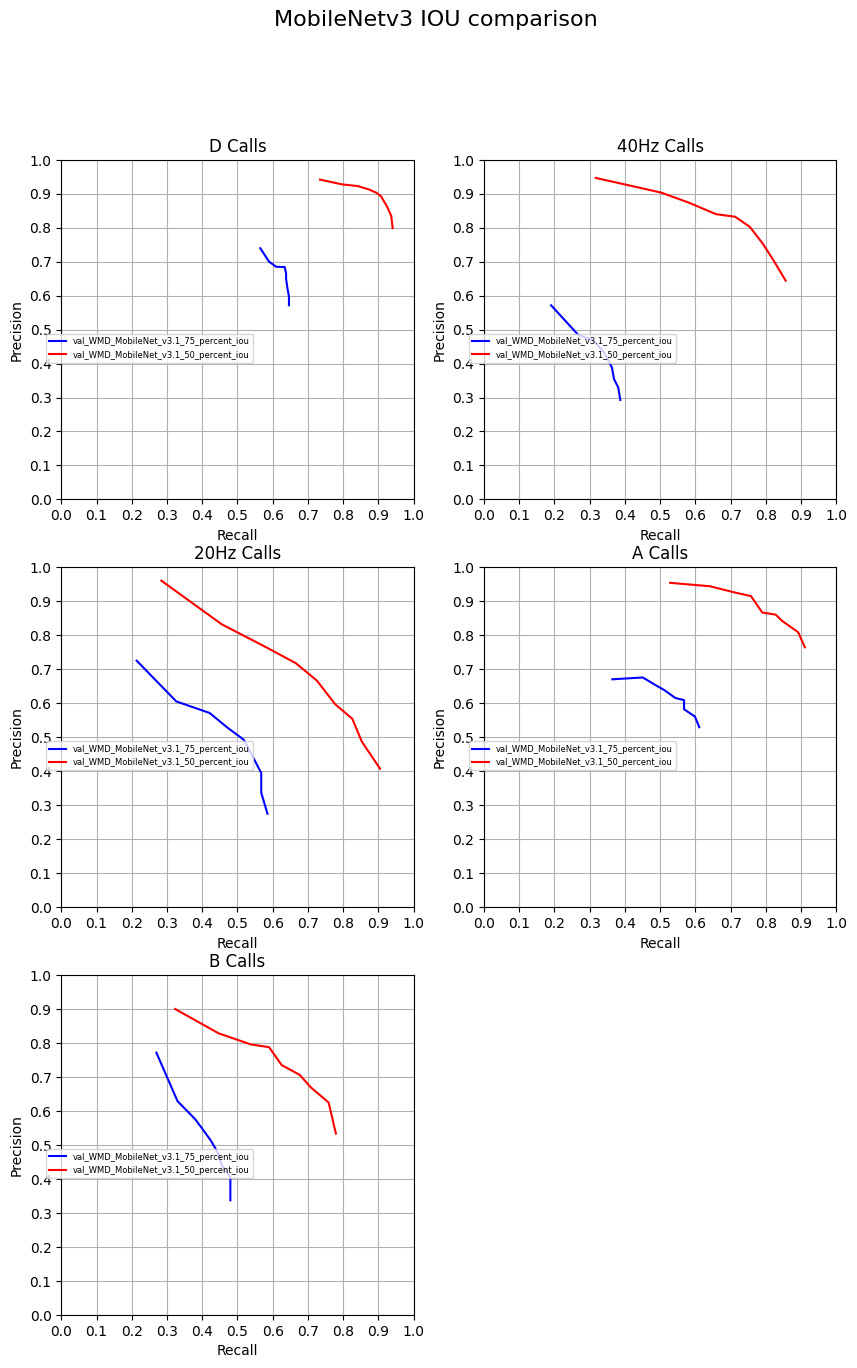

In [280]:
model_names = ["WMD_ResNet_18", "WMD_MobileNet_v3", "WMD_BEST", "WMD_MobileNet_v3.1"]
evaluation_folder_path = "C:/Users/Shane/Documents/Classes/Scripps/evaluation"


#plot_epoch_curves("WMD_ResNet_18", evaluation_folder_path, skip_each = 10)
#plot_model_curves(model_names, evaluation_folder_path)
#plot_model_curves(model_names, evaluation_folder_path)
#plot_curves(["val_WMD_MobileNet_v3.1_75_percent_iou", "val_WMD_MobileNet_v3.1_50_percent_iou"], evaluation_folder_path)

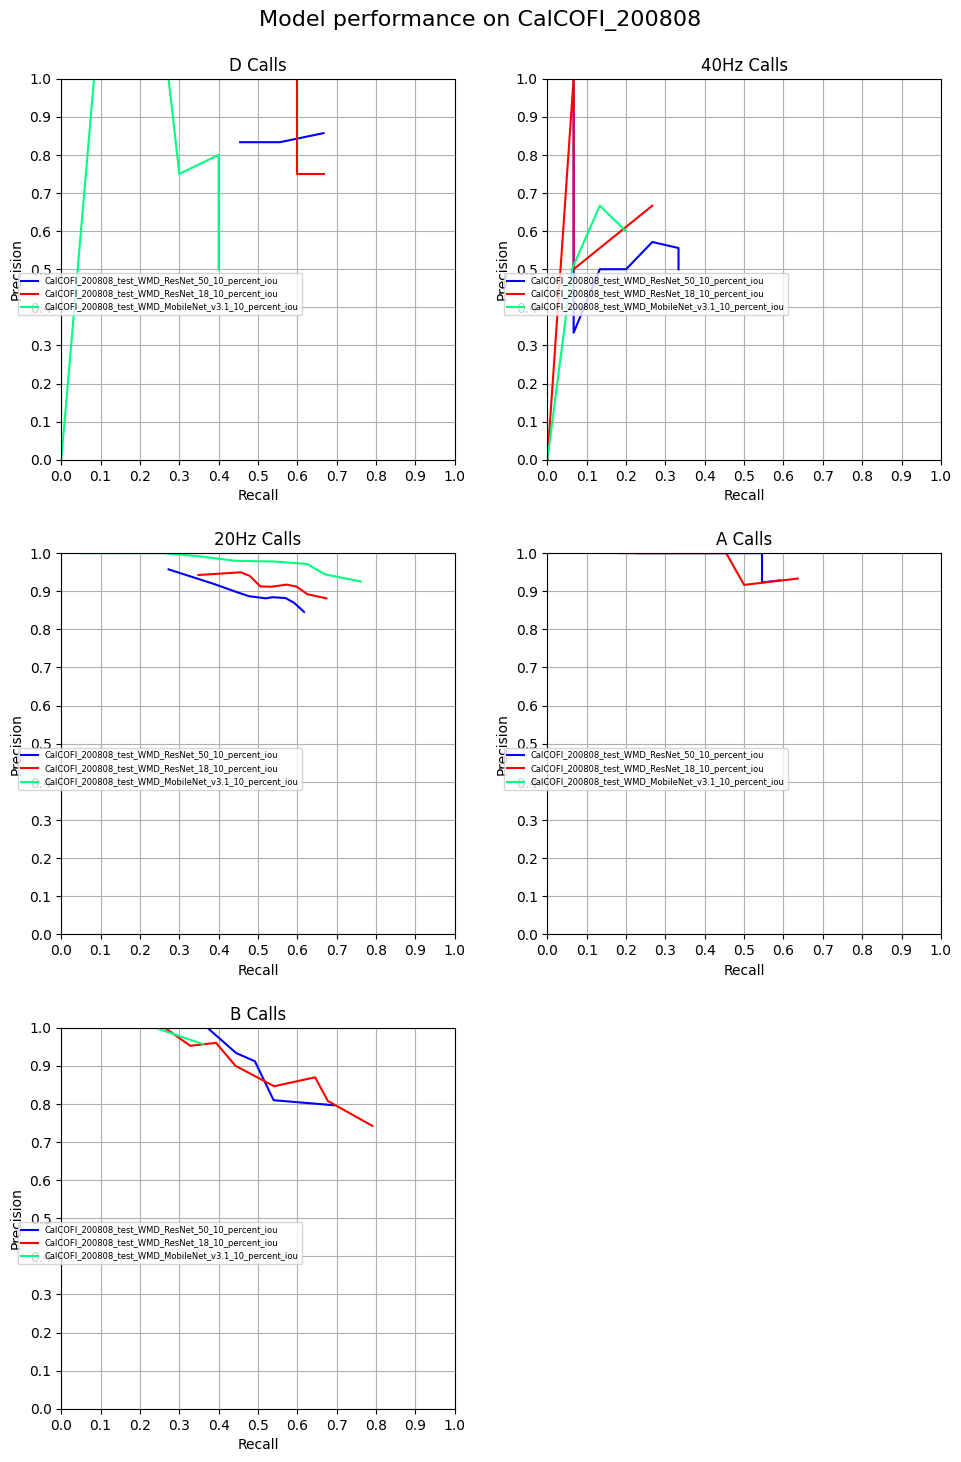

In [286]:
plot_curves(
    ["val_WMD_ResNet_50_10_percent_iou", "val_WMD_ResNet_18_10_percent_iou", "val_test_WMD_MobileNet_v3.1_10_percent_iou"], 
    evaluation_folder_path,
    "val_comparison",
    "Model performance on validation set"
)

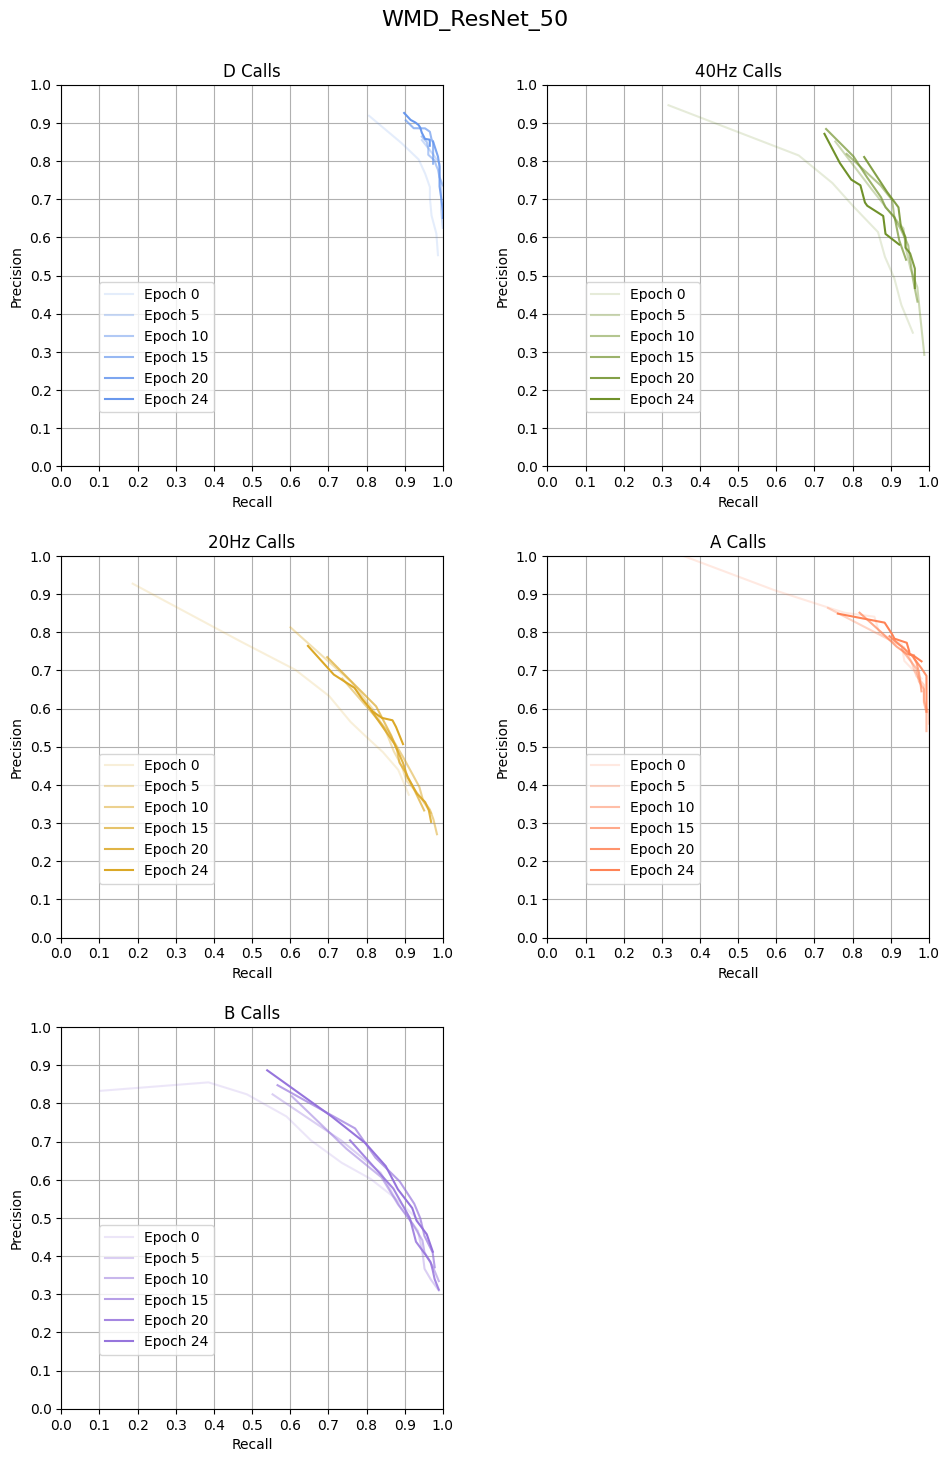

In [282]:
plot_epoch_curves("WMD_ResNet_50", evaluation_folder_path, skip_each = 5)

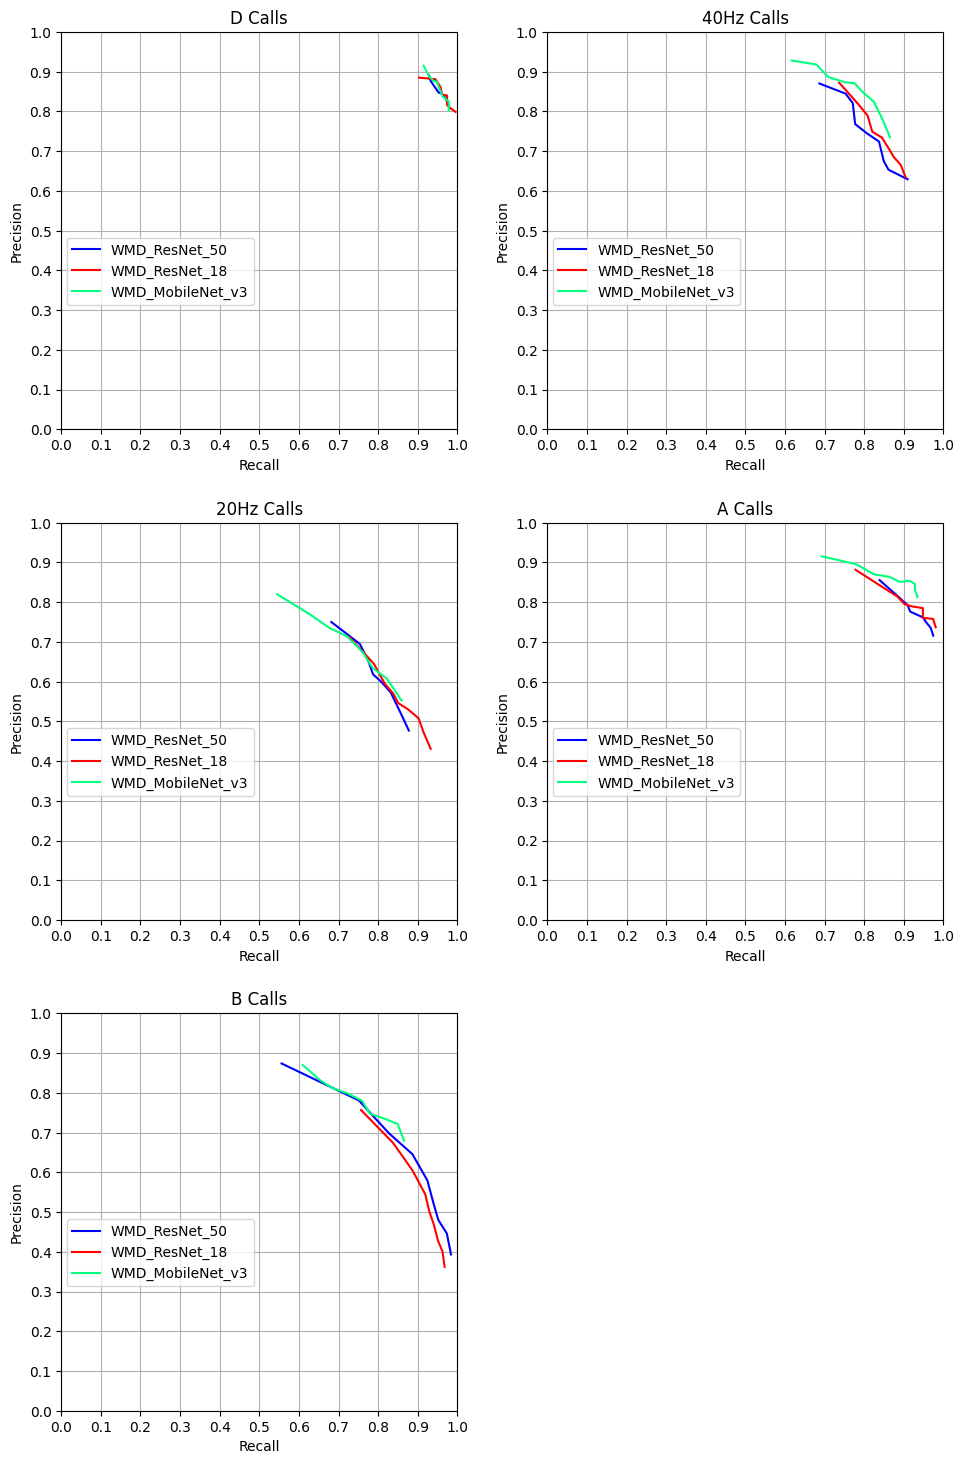

In [283]:
model_names = ["WMD_ResNet_50", "WMD_ResNet_18", "WMD_MobileNet_v3"]

plot_model_curves(model_names, evaluation_folder_path)

In [284]:
length_funct = len
test_list = [1, 2, 3]
print(length_funct(test_list))

3
